# ANFIS Breast Cancer — Grid Search (80/20 · 70/30 · 60/40)

Notebook huấn luyện ANFIS trên WBCD (UCI), chọn 3 đặc trưng theo paper (v1, v2, v3), hệ mờ **27 luật grid** (Gaussian low/medium/high), grid search hyperparameter.

| Mục | Nội dung |
|-----|----------|
| **1** | Tiền xử lý WBCD → 663 mẫu, 3 feature PCA |
| **2** | Hệ mờ FS: MF Gaussian + **27 luật** (hiển thị đầy đủ) |
| **3** | Grid search: 3 split × 3 LR × 4 epoch |
| **4** | Bảng kết quả & pivot accuracy |
| **5** | Biểu đồ + lưu PNG vào `plots/` (CM chung, loss + accuracy riêng) |
| **6** | Xuất mô hình & artifact vào `models/` (checkpoint, scaler, meta, metrics) |
| **7** | Tóm tắt cấu hình tốt nhất mỗi split |
| **8** | Xuất nhật ký HTML vào `nhat-ky/` |

## 0. Import & cấu hình

In [12]:
import warnings
warnings.filterwarnings("ignore")

import itertools
import json
import pickle
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from skanfis import scikit_anfis
from skanfis.fs import FS, LinguisticVariable, GaussianFuzzySet
from skanfis.experimental import RMSELoss

plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white", "font.size": 11})
print("Torch:", torch.__version__)

Torch: 2.12.1+cpu


In [13]:
SPLIT_RATIOS = {"80-20": 0.2, "70-30": 0.3, "60-40": 0.4}
SPLIT_TITLES = {
    "80-20": "80 - 20% train-test",
    "70-30": "70 - 30% train-test",
    "60-40": "60 - 40% train-test",
}
LEARNING_RATES = [0.001, 0.01, 0.05]
EPOCH_LIST = [25, 50, 75, 100]
LR_COLORS = {0.001: "#f4a261", 0.01: "#8ecae6", 0.05: "#b39ddb"}
LR_LABELS = {0.001: "0.001", 0.01: "0.01", 0.05: "0.05"}

STAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_TAG = "gridsearch_pca_feature_select"

OUT_DIR = Path("models")
PLOT_DIR = Path("plots")
LOG_DIR = Path("nhat-ky")
OUT_DIR.mkdir(exist_ok=True)
PLOT_DIR.mkdir(exist_ok=True)
LOG_DIR.mkdir(exist_ok=True)
RESULTS_PATH = OUT_DIR / "hyperparam_grid_results.csv"

## 1. Tiền xử lý dữ liệu WBCD

- Load UCI Breast Cancer Wisconsin (Original)
- Loại outlier Euclidean, chuẩn hóa 9 feature
- PCA → chọn **v1, v2, v3** (clump thickness, cell size, cell shape)
- Giảm còn **663 mẫu** (quality-based drop, bám paper)

In [14]:
uci_url = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/"
    "breast-cancer-wisconsin/breast-cancer-wisconsin.data"
)
cols = [
    "sample_code_number", "clump_thickness", "uniformity_of_cell_size",
    "uniformity_of_cell_shape", "marginal_adhesion", "single_epithelial_cell_size",
    "bare_nuclei", "bland_chromatin", "normal_nucleoli", "mitoses", "class",
]
feature_cols = [
    "clump_thickness", "uniformity_of_cell_size", "uniformity_of_cell_shape",
    "marginal_adhesion", "single_epithelial_cell_size", "bare_nuclei",
    "bland_chromatin", "normal_nucleoli", "mitoses",
]
feature_name_map = {
    "clump_thickness": "Clump Thickness",
    "uniformity_of_cell_size": "Uniformity of Cell Size",
    "uniformity_of_cell_shape": "Uniformity of Cell Shape",
    "marginal_adhesion": "Marginal Adhesion",
    "single_epithelial_cell_size": "Single Epithelial Cell Size",
    "bare_nuclei": "Bare Nuclei",
    "bland_chromatin": "Bland Chromatin",
    "normal_nucleoli": "Normal Nucleoli",
    "mitoses": "Mitoses",
}
PAPER_TOP3_FEATURES = [
    "clump_thickness", "uniformity_of_cell_size", "uniformity_of_cell_shape",
]
FS_VAR_NAMES = {
    "clump_thickness": "ClumpThickness",
    "uniformity_of_cell_size": "CellSize",
    "uniformity_of_cell_shape": "CellShape",
}
FS_DISPLAY_NAMES = {v: feature_name_map[k] for k, v in FS_VAR_NAMES.items()}
LINGUISTIC_TERMS = ("low", "medium", "high")

df = pd.read_csv(uci_url, header=None, names=cols)
df = df.replace("?", np.nan).dropna().copy()
df["bare_nuclei"] = df["bare_nuclei"].astype(int)
df["target"] = (df["class"] == 4).astype(int)
X = df[feature_cols].values.astype(np.float32)
y = df["target"].values.astype(int)

OUTLIER_STD_MULTIPLIER = 2.5
data_center = X.mean(axis=0)
euclidean_distances = np.linalg.norm(X - data_center, axis=1)
outlier_threshold = euclidean_distances.mean() + OUTLIER_STD_MULTIPLIER * euclidean_distances.std()
keep_mask = euclidean_distances <= outlier_threshold
X_clean, y_clean = X[keep_mask], y[keep_mask]

scaler = StandardScaler()
X_norm = scaler.fit_transform(X_clean).astype(np.float32)
pca_full = PCA(n_components=9, random_state=42)
pca_full.fit(X_norm)

pca_table_df = pd.DataFrame({
    "Attribute No.": np.arange(1, len(feature_cols) + 1),
    "feature_col": feature_cols,
    "Feature": [feature_name_map[c] for c in feature_cols],
    "Percentage of Importance": (100.0 * pca_full.explained_variance_ratio_).round(4),
})
print("Bảng 8 — PCA trên 9 feature chuẩn hóa:")
display(pca_table_df[["Attribute No.", "Feature", "Percentage of Importance"]])

selected_idx = [feature_cols.index(c) for c in PAPER_TOP3_FEATURES]
X_selected = X_norm[:, selected_idx].astype(np.float32)

n_drop = len(X_selected) - 663
centroid_benign = X_selected[y_clean == 0].mean(axis=0)
centroid_malignant = X_selected[y_clean == 1].mean(axis=0)
dist_to_benign = np.linalg.norm(X_selected - centroid_benign, axis=1)
dist_to_malignant = np.linalg.norm(X_selected - centroid_malignant, axis=1)
own_dist = np.where(y_clean == 0, dist_to_benign, dist_to_malignant)
other_dist = np.where(y_clean == 0, dist_to_malignant, dist_to_benign)
quality_score = other_dist - own_dist
drop_idx = np.argsort(quality_score)[:n_drop]
quality_keep_mask = np.ones(len(X_selected), dtype=bool)
quality_keep_mask[drop_idx] = False
indices = np.where(quality_keep_mask)[0]
X_663 = X_selected[indices]
y_663 = y_clean[indices].astype(np.float32)

df_clean = df.loc[keep_mask].reset_index(drop=True)
QUALITY_DROPPED_SAMPLE_IDS = df_clean.iloc[drop_idx]["sample_code_number"].astype(int).tolist()

print(f"\nDataset sẵn sàng: {X_663.shape}, tỷ lệ ác tính = {y_663.mean():.4f}")
print("3 feature ANFIS:", PAPER_TOP3_FEATURES)

Bảng 8 — PCA trên 9 feature chuẩn hóa:


,Attribute No.,Feature,Percentage of Importance
0,1,Clump Thickness,62.536301
1,2,Uniformity of Cell Size,9.301200
2,3,Uniformity of Cell Shape,6.227000
3,4,Marginal Adhesion,5.730000
4,5,Single Epithelial Cell Size,4.661500
5,6,Bare Nuclei,3.737100
6,7,Bland Chromatin,3.498900
7,8,Normal Nucleoli,3.184500
8,9,Mitoses,1.123500



Dataset sẵn sàng: (663, 3), tỷ lệ ác tính = 0.3333
3 feature ANFIS: ['clump_thickness', 'uniformity_of_cell_size', 'uniformity_of_cell_shape']


## 2. Hệ mờ FS — Hàm thành viên Gaussian & 27 luật grid

- 3 input × 3 MF Gaussian (low / medium / high) → **grid partitioning 3³ = 27 luật**
- THEN khởi tạo `out IS 0.5`, consequent học được (`zerotype=False`)
- Huấn luyện hybrid: LSE (consequent) + SGD (premise/MF)

In [15]:
def build_fs_and_rules(X_train):
    """Tạo FS + danh sách 27 luật grid (chưa gắn model)."""
    fs = FS()
    mf_init_log = []
    for feat_col in PAPER_TOP3_FEATURES:
        fs_var = FS_VAR_NAMES[feat_col]
        col = X_train[:, PAPER_TOP3_FEATURES.index(feat_col)]
        col_min, col_max = float(col.min()), float(col.max())
        centers = np.linspace(col_min, col_max, 3).tolist()
        sigma = max((col_max - col_min) / 3.0, 1e-3)
        mf_low = GaussianFuzzySet(mu=centers[0], sigma=sigma, term="low")
        mf_med = GaussianFuzzySet(mu=centers[1], sigma=sigma, term="medium")
        mf_high = GaussianFuzzySet(mu=centers[2], sigma=sigma, term="high")
        fs.add_linguistic_variable(
            fs_var,
            LinguisticVariable([mf_low, mf_med, mf_high], concept=FS_DISPLAY_NAMES[fs_var]),
        )
        mf_init_log.append({
            "Input": FS_DISPLAY_NAMES[fs_var],
            "mu (low, med, high)": [round(c, 4) for c in centers],
            "sigma": round(sigma, 4),
        })
    fs.set_crisp_output_value("out", 0)
    grid_rules = []
    for ct, cs, csh in itertools.product(LINGUISTIC_TERMS, repeat=3):
        grid_rules.append(
            f"IF (ClumpThickness IS {ct}) AND (CellSize IS {cs}) AND (CellShape IS {csh}) "
            f"THEN (out IS 0.5)"
        )
    fs.add_rules(grid_rules)
    return fs, grid_rules, pd.DataFrame(mf_init_log)


def build_fs_and_model(X_train, epochs):
    fs, _, _ = build_fs_and_rules(X_train)
    return scikit_anfis(
        fs,
        description="WBCD_Gaussian27_GridSearch",
        epoch=epochs,
        hybrid=True,
        label="c",
        zerotype=False,
    )


def clamp_gaussian_sigma(model, min_sigma=1e-3):
    with torch.no_grad():
        for fuzzify_var in model.layer["fuzzify"].varmfs.values():
            for mf in fuzzify_var.mfdefs.values():
                if hasattr(mf, "sigma"):
                    mf.sigma.data.clamp_(min=min_sigma)


def train_model(model, X_train, y_train, epochs, learning_rate, return_history=False):
    optimizer = torch.optim.SGD(model.layer["fuzzify"].parameters(), lr=learning_rate)
    criterion = RMSELoss()
    X_train_t = torch.from_numpy(X_train).float()
    y_train_t = torch.from_numpy(y_train).float().unsqueeze(-1)
    history = []
    model.train()
    for ep in range(1, epochs + 1):
        with torch.no_grad():
            model.is_training = True
            model(X_train_t, y_train_t)
        model.is_training = False
        y_pred = model(X_train_t, y_train_t)
        optimizer.zero_grad()
        loss = criterion(y_pred, y_train_t)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.layer["fuzzify"].parameters(), 1.0)
        optimizer.step()
        clamp_gaussian_sigma(model)
        mse = torch.nn.functional.mse_loss(y_pred, y_train_t).item()
        rmse = float(np.sqrt(mse))
        history.append({"epoch": ep, "rmse": rmse, "loss": float(loss.item())})
    model.eval()
    model.is_training = False
    if return_history:
        return model, pd.DataFrame(history)
    return model


def predict_binary(model, X):
    with torch.no_grad():
        y_pred = model(torch.from_numpy(X).float()).detach().numpy()
    return np.clip(np.round(y_pred), 0, 1).astype(int)

In [16]:
# Khởi tạo FS từ toàn bộ 663 mẫu (chỉ để hiển thị MF + luật)
_, GRID_RULES, membership_df = build_fs_and_rules(X_663)

TERM_LABELS = {
    "low": "Thấp (low)",
    "medium": "Trung bình (medium)",
    "high": "Cao (high)",
}


def prettify_rule(rule: str) -> dict:
    if_part, then_part = rule.split(" THEN ")
    if_text = if_part.replace("IF ", "", 1)
    for fs_var, display in FS_DISPLAY_NAMES.items():
        if_text = if_text.replace(fs_var, display)
    for term, label in TERM_LABELS.items():
        if_text = if_text.replace(f" IS {term}", f" IS {label}")
    return {"IF": if_text, "THEN": then_part.strip()}


fuzzy_rules_df = pd.DataFrame(
    [{"Rule": i, **prettify_rule(r)} for i, r in enumerate(GRID_RULES, start=1)]
)

print(f"Hàm thành viên Gaussian — 3 term / input ({len(membership_df)} dòng)")
display(membership_df)

print(f"\n27 luật mờ grid (3³ partitioning) — hiển thị đầy đủ:")
display(fuzzy_rules_df)

 * Detected Sugeno model type
Hàm thành viên Gaussian — 3 term / input (3 dòng)


,Input,"mu (low, med, high)",sigma
0,Clump Thickness,"[-1.2045, 0.417, 2.0384]",1.0810
1,Uniformity of Cell Size,"[-0.6809, 0.8781, 2.4372]",1.0394
2,Uniformity of Cell Shape,"[-0.7237, 0.8793, 2.4824]",1.0687



27 luật mờ grid (3³ partitioning) — hiển thị đầy đủ:


,Rule,IF,THEN
0,1,(Clump Thickness IS Thấp (low)) AND (Uniformit...,(out IS 0.5)
1,2,(Clump Thickness IS Thấp (low)) AND (Uniformit...,(out IS 0.5)
2,3,(Clump Thickness IS Thấp (low)) AND (Uniformit...,(out IS 0.5)
3,4,(Clump Thickness IS Thấp (low)) AND (Uniformit...,(out IS 0.5)
4,5,(Clump Thickness IS Thấp (low)) AND (Uniformit...,(out IS 0.5)
5,6,(Clump Thickness IS Thấp (low)) AND (Uniformit...,(out IS 0.5)
6,7,(Clump Thickness IS Thấp (low)) AND (Uniformit...,(out IS 0.5)
7,8,(Clump Thickness IS Thấp (low)) AND (Uniformit...,(out IS 0.5)
8,9,(Clump Thickness IS Thấp (low)) AND (Uniformit...,(out IS 0.5)
9,10,(Clump Thickness IS Trung bình (medium)) AND (...,(out IS 0.5)


## 3. Grid search — 3 tỷ lệ split × 3 learning rate × 4 epoch

| Split | Test size | Train ~ |
|-------|-----------|--------|
| 80/20 | 20% | 530 |
| 70/30 | 30% | 464 |
| 60/40 | 40% | 397 |

**Learning rate:** 0.001 · 0.01 · 0.05  
**Epoch:** 25 · 50 · 75 · 100  
→ Tổng **36** cấu hình (một lần chạy notebook)

In [17]:
results = []
total = len(SPLIT_RATIOS) * len(LEARNING_RATES) * len(EPOCH_LIST)
run_idx = 0

for split_label, test_size in SPLIT_RATIOS.items():
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_663, y_663, test_size=test_size, random_state=42, stratify=y_663,
    )
    for lr in LEARNING_RATES:
        for n_epochs in EPOCH_LIST:
            run_idx += 1
            print(f"[{run_idx}/{total}] split={split_label} lr={lr} epochs={n_epochs} ...", flush=True)
            model = build_fs_and_model(X_tr, n_epochs)
            model = train_model(model, X_tr, y_tr, n_epochs, lr)
            acc = accuracy_score(y_te.astype(int), predict_binary(model, X_te))
            results.append({
                "split_ratio": split_label,
                "test_size": test_size,
                "train_size": len(X_tr),
                "test_n": len(X_te),
                "learning_rate": lr,
                "epochs": n_epochs,
                "test_accuracy": acc,
                "test_accuracy_pct": round(acc * 100, 2),
            })
            print(f"  -> accuracy = {acc * 100:.2f}%", flush=True)

grid_df = pd.DataFrame(results)
grid_df.to_csv(RESULTS_PATH, index=False)
print(f"\nĐã lưu {len(grid_df)} dòng → {RESULTS_PATH}")

[1/36] split=80-20 lr=0.001 epochs=25 ...
 * Detected Sugeno model type
  -> accuracy = 88.72%
[2/36] split=80-20 lr=0.001 epochs=50 ...
 * Detected Sugeno model type
  -> accuracy = 88.72%
[3/36] split=80-20 lr=0.001 epochs=75 ...
 * Detected Sugeno model type
  -> accuracy = 88.72%
[4/36] split=80-20 lr=0.001 epochs=100 ...
 * Detected Sugeno model type
  -> accuracy = 88.72%
[5/36] split=80-20 lr=0.01 epochs=25 ...
 * Detected Sugeno model type
  -> accuracy = 87.97%
[6/36] split=80-20 lr=0.01 epochs=50 ...
 * Detected Sugeno model type
  -> accuracy = 90.98%
[7/36] split=80-20 lr=0.01 epochs=75 ...
 * Detected Sugeno model type
  -> accuracy = 90.98%
[8/36] split=80-20 lr=0.01 epochs=100 ...
 * Detected Sugeno model type
  -> accuracy = 90.98%
[9/36] split=80-20 lr=0.05 epochs=25 ...
 * Detected Sugeno model type
  -> accuracy = 92.48%
[10/36] split=80-20 lr=0.05 epochs=50 ...
 * Detected Sugeno model type
  -> accuracy = 95.49%
[11/36] split=80-20 lr=0.05 epochs=75 ...
 * Detected

## 4. Bảng kết quả grid search

In [18]:
display(grid_df.sort_values(["split_ratio", "epochs", "learning_rate"]))

for split_label in SPLIT_RATIOS:
    print(f"\n=== Pivot accuracy (%) — {SPLIT_TITLES[split_label]} ===")
    pivot = grid_df[grid_df["split_ratio"] == split_label].pivot_table(
        index="epochs", columns="learning_rate", values="test_accuracy_pct"
    )
    display(pivot)

,split_ratio,test_size,train_size,test_n,learning_rate,epochs,test_accuracy,test_accuracy_pct
24,60-40,0.4,397,266,0.001,25,0.894737,89.47
28,60-40,0.4,397,266,0.010,25,0.898496,89.85
32,60-40,0.4,397,266,0.050,25,0.860902,86.09
25,60-40,0.4,397,266,0.001,50,0.894737,89.47
29,60-40,0.4,397,266,0.010,50,0.898496,89.85
33,60-40,0.4,397,266,0.050,50,0.842105,84.21
26,60-40,0.4,397,266,0.001,75,0.894737,89.47
30,60-40,0.4,397,266,0.010,75,0.864662,86.47
34,60-40,0.4,397,266,0.050,75,0.853383,85.34
27,60-40,0.4,397,266,0.001,100,0.894737,89.47



=== Pivot accuracy (%) — 80 - 20% train-test ===


learning_rate,0.001,0.010,0.050
epochs,,,
25,88.72,87.97,92.48
50,88.72,90.98,95.49
75,88.72,90.98,95.49
100,88.72,90.98,91.73



=== Pivot accuracy (%) — 70 - 30% train-test ===


learning_rate,0.001,0.010,0.050
epochs,,,
25,88.94,91.46,90.95
50,88.94,91.46,91.96
75,91.96,90.95,88.44
100,91.46,92.46,95.98



=== Pivot accuracy (%) — 60 - 40% train-test ===


learning_rate,0.001,0.010,0.050
epochs,,,
25,89.47,89.85,86.09
50,89.47,89.85,84.21
75,89.47,86.47,85.34
100,89.47,86.47,91.35


## 5. Biểu đồ, xuất mô hình & lưu PNG

Mỗi tỷ lệ split (80/20 · 70/30 · 60/40), huấn luyện lại cấu hình tốt nhất rồi lưu:

**Biểu đồ** → `plots/` (3 file / split):

| File | Nội dung |
|------|----------|
| `plots/split_cm_*.png` | Confusion matrix train + test (chung 1 hình) |
| `plots/split_loss_*.png` | Epoch vs RMSE (config tốt nhất) |
| `plots/hyperparam_accuracy_*.png` | Accuracy (%) theo epoch / learning rate |

**Mô hình** → `models/` (mỗi split):

| File | Nội dung |
|------|----------|
| `{stamp}_{run_tag}_{split}_best_model.pkl` | Checkpoint ANFIS |
| `{stamp}_{run_tag}_{split}_metrics.json` | Metric train/test |
| `{stamp}_{run_tag}_{split}_training_loss_log.csv` | RMSE theo epoch |
| `{stamp}_{run_tag}_{split}_membership_functions.csv` | MF sau huấn luyện |

In [19]:
CM_LABELS = [
    ("True Negative", (0, 0)),
    ("False Positive", (0, 1)),
    ("False Negative", (1, 0)),
    ("True Positive", (1, 1)),
]


def best_config_for_split(split_label):
    sub = grid_df[grid_df["split_ratio"] == split_label]
    best = sub.loc[sub["test_accuracy"].idxmax()]
    return float(best["learning_rate"]), int(best["epochs"]), float(best["test_accuracy_pct"])


def plot_confusion_matrix(ax, y_true, y_pred, title):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    total = cm.sum()
    sns.heatmap(
        cm, annot=False, cmap="YlOrRd", cbar=True, vmin=0,
        vmax=max(int(cm.max()), 1),
        xticklabels=["Benign", "Malignant"],
        yticklabels=["Benign", "Malignant"],
        linewidths=2, linecolor="white", ax=ax,
    )
    for label, (r, c) in CM_LABELS:
        count = int(cm[r, c])
        pct = 100.0 * count / total if total else 0.0
        ax.text(c + 0.5, r + 0.5, f"{label}\n{count}\n{pct:.2f}%",
                ha="center", va="center", fontsize=10)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.text(
        0.5, -0.22,
        f"Accuracy={acc:.3f}  Precision={prec:.3f}  Recall={rec:.3f}  F1={f1:.3f}",
        transform=ax.transAxes, ha="center", va="top", fontsize=10,
    )


def plot_loss_curve(ax, history_df, lr, epochs, best_acc_pct):
    ax.plot(history_df["epoch"], history_df["rmse"], color="#1f77b4", linewidth=2, label="Train RMSE")
    best_idx = history_df["rmse"].idxmin()
    best_ep = int(history_df.loc[best_idx, "epoch"])
    best_rmse = float(history_df.loc[best_idx, "rmse"])
    ax.scatter([best_ep], [best_rmse], color="#2ca02c", s=80, zorder=5,
               label=f"Best ep={best_ep}, RMSE={best_rmse:.4f}")
    ax.set_title(
        f"Hàm loss (RMSE) — lr={lr}, epochs={epochs}, test acc={best_acc_pct:.2f}%",
        fontsize=12, fontweight="bold",
    )
    ax.set_xlabel("Epoch")
    ax.set_ylabel("RMSE")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def plot_grouped_accuracy(split_label, ax=None):
    sub = grid_df[grid_df["split_ratio"] == split_label].copy()
    bar_width = 0.22
    x = np.arange(len(EPOCH_LIST))
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 5.5))
    else:
        fig = ax.figure
    for i, lr in enumerate(LEARNING_RATES):
        vals = [
            float(sub[(sub["epochs"] == ep) & (sub["learning_rate"] == lr)]["test_accuracy_pct"].iloc[0])
            for ep in EPOCH_LIST
        ]
        offset = (i - (len(LEARNING_RATES) - 1) / 2) * bar_width
        bars = ax.bar(
            x + offset, vals, width=bar_width,
            color=LR_COLORS[lr], label=LR_LABELS[lr], edgecolor="none", alpha=0.92,
        )
        for bar, val in zip(bars, vals):
            ax.text(
                bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
                f"{val:.2f}", ha="center", va="bottom", rotation=90, fontsize=9,
            )
    ax.set_title(SPLIT_TITLES[split_label], fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Epoch theo learning rate")
    ax.set_ylabel("Accuracy (%)")
    ax.set_xticks(x)
    ax.set_xticklabels([str(e) for e in EPOCH_LIST])
    ax.set_ylim(0, 105)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return fig, ax


split_exports = {}


def evaluate_split_metrics(y_true, y_pred, split_name):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    return {
        "split": split_name,
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1_score": float(f1_score(y_true, y_pred, zero_division=0)),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        "support": int(len(y_true)),
    }


def mf_init_log_from_train(X_train):
    _, _, mf_df = build_fs_and_rules(X_train)
    return [
        {
            "var": row["Input"],
            "mu": row["mu (low, med, high)"],
            "sigma": float(row["sigma"]),
        }
        for _, row in mf_df.iterrows()
    ]


def export_trained_membership(model):
    rows = []
    for fs_var, fuzzify_var in model.layer["fuzzify"].varmfs.items():
        display_name = FS_DISPLAY_NAMES.get(fs_var, fs_var)
        for term, mf in fuzzify_var.mfdefs.items():
            rows.append({
                "Input": display_name,
                "Linguistic term": TERM_LABELS.get(term, term),
                "mu (center)": round(float(mf.mu.item()), 4),
                "sigma": round(float(mf.sigma.item()), 4),
            })
    return pd.DataFrame(rows)

 * Detected Sugeno model type


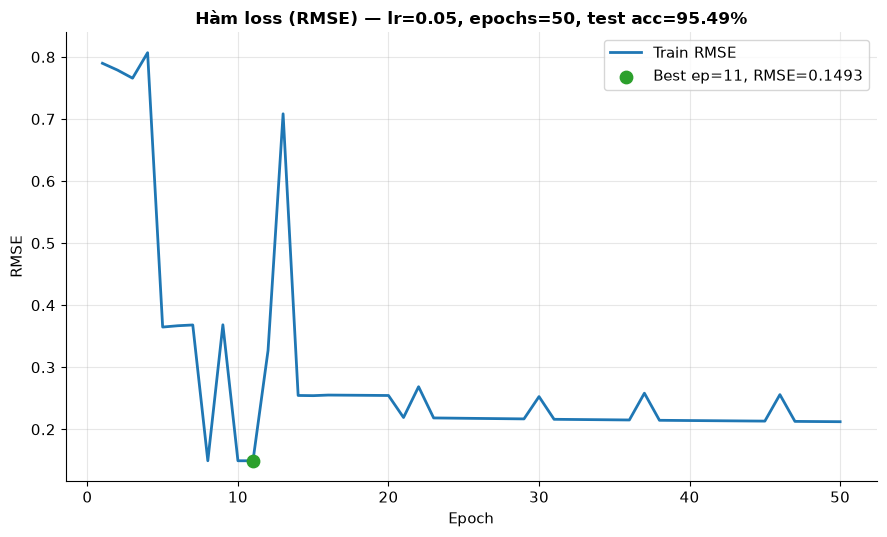

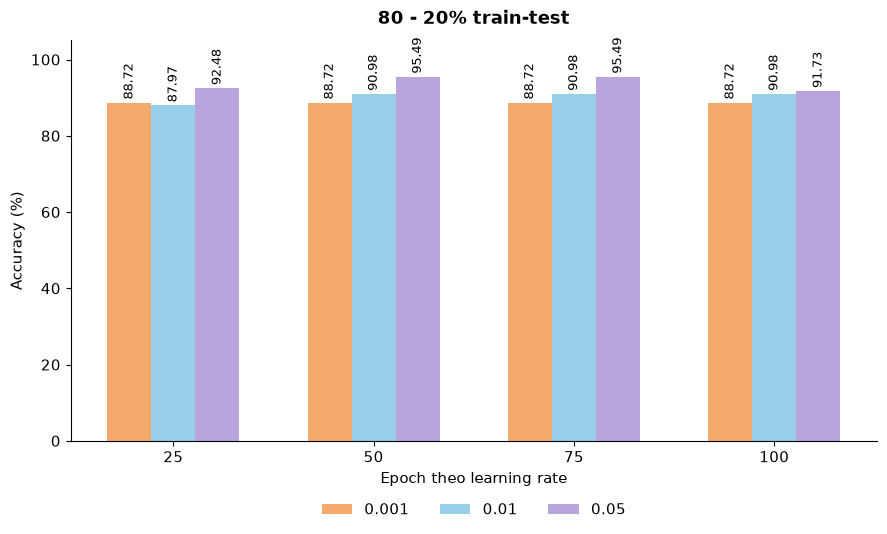

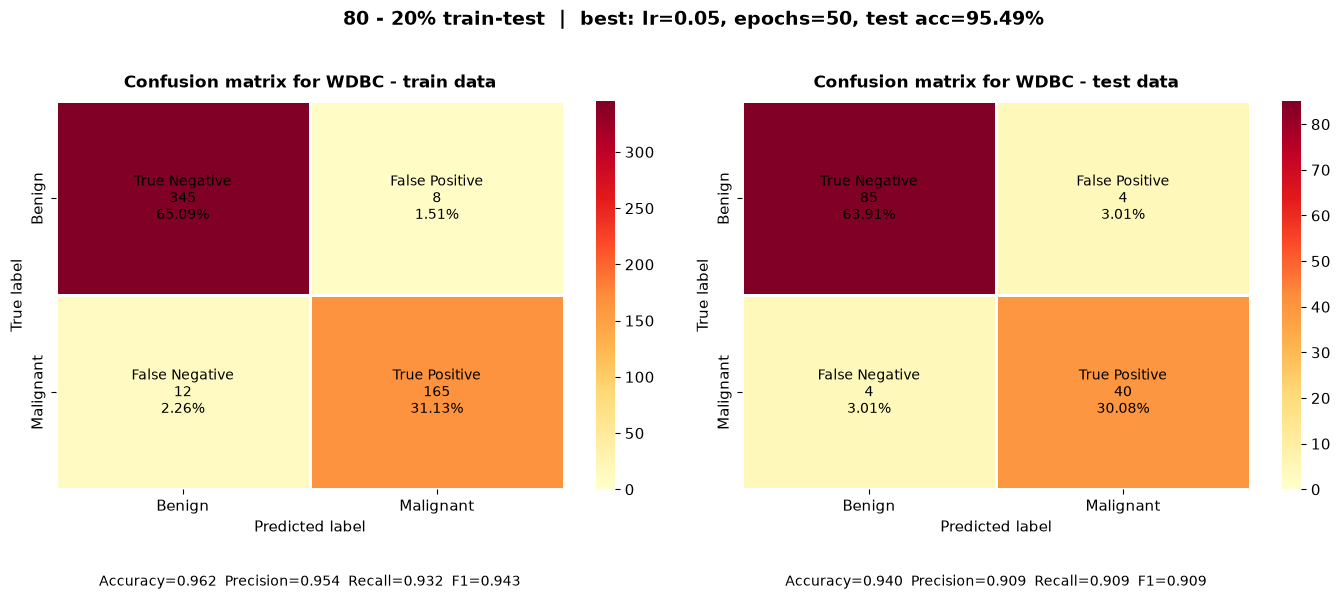

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

Saved: plots\split_cm_80_20.png
Saved: plots\split_loss_80_20.png  (lr=0.05, epochs=50)
Saved: plots\hyperparam_accuracy_80_20.png
 * Detected Sugeno model type
Exported model: models\20260628_172814_gridsearch_pca_feature_select_80_20_best_model.pkl
 * Detected Sugeno model type


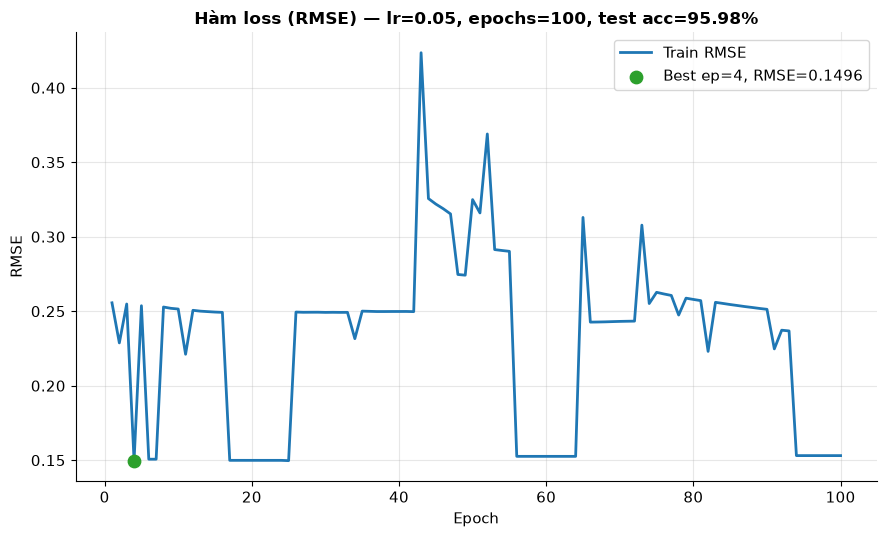

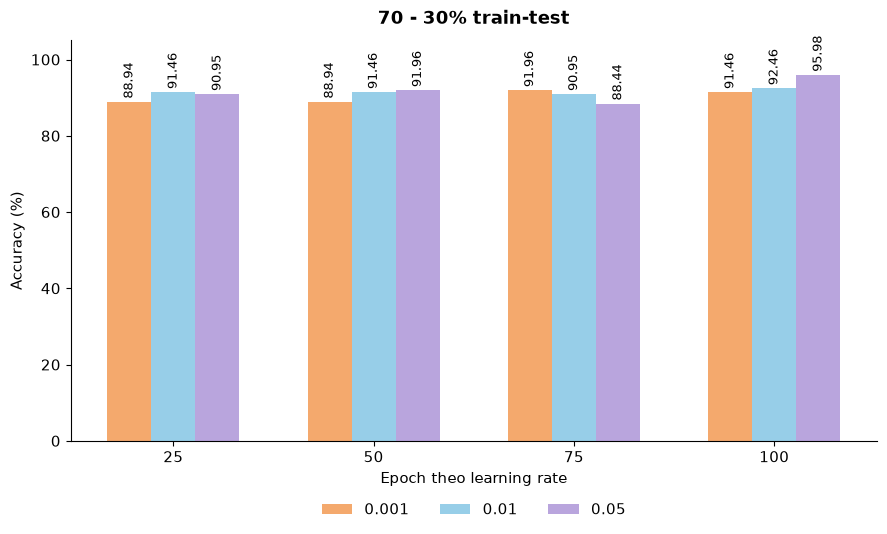

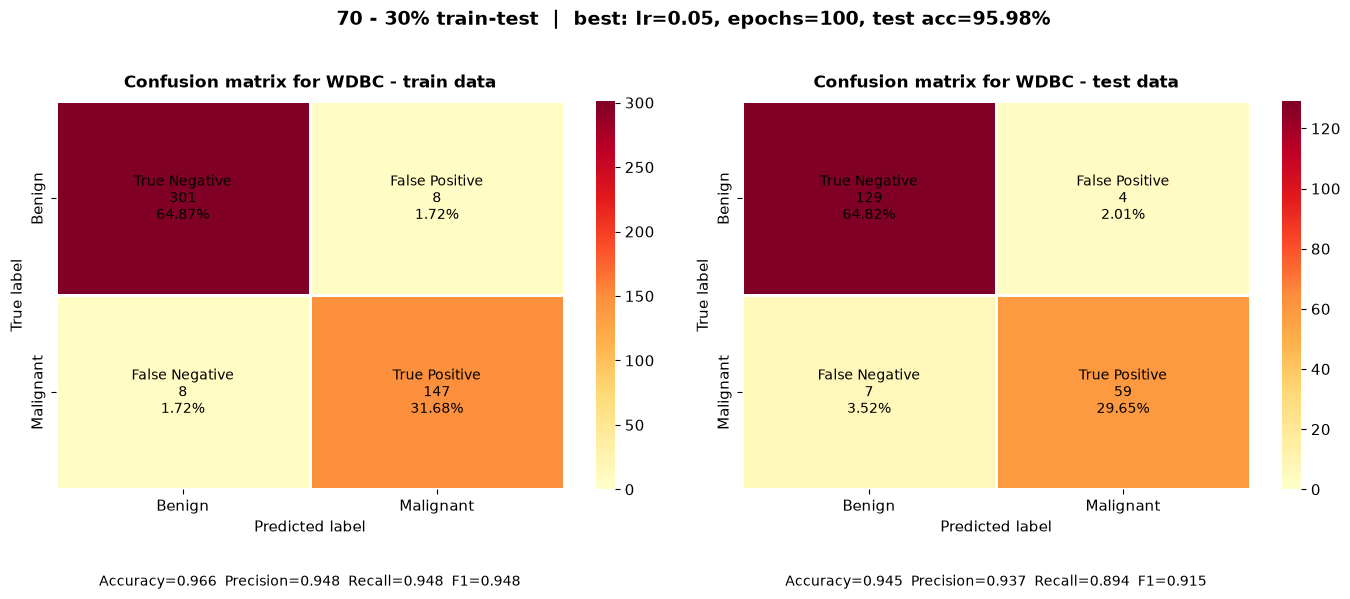

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

Saved: plots\split_cm_70_30.png
Saved: plots\split_loss_70_30.png  (lr=0.05, epochs=100)
Saved: plots\hyperparam_accuracy_70_30.png
 * Detected Sugeno model type
Exported model: models\20260628_172814_gridsearch_pca_feature_select_70_30_best_model.pkl
 * Detected Sugeno model type


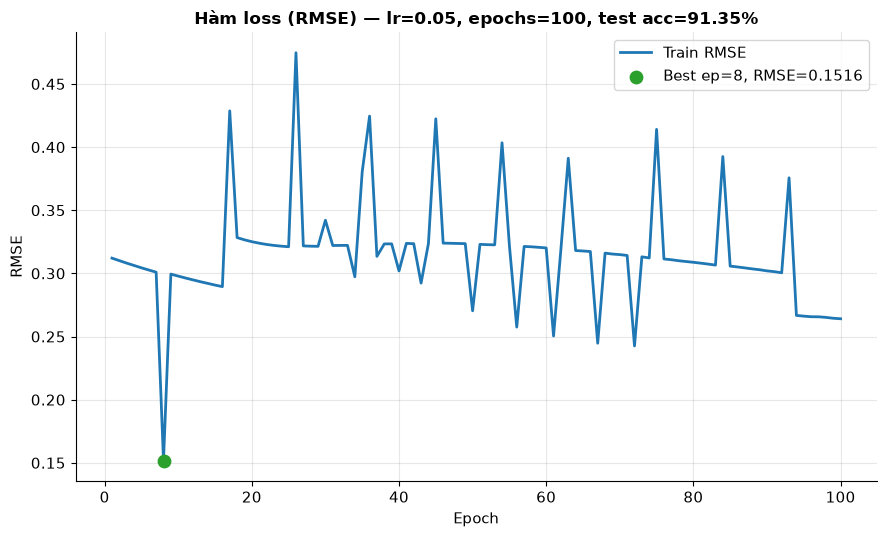

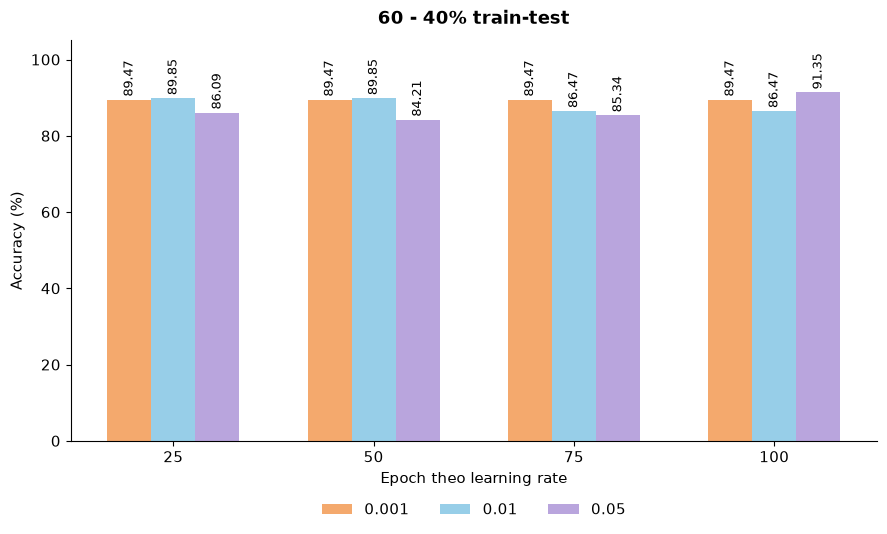

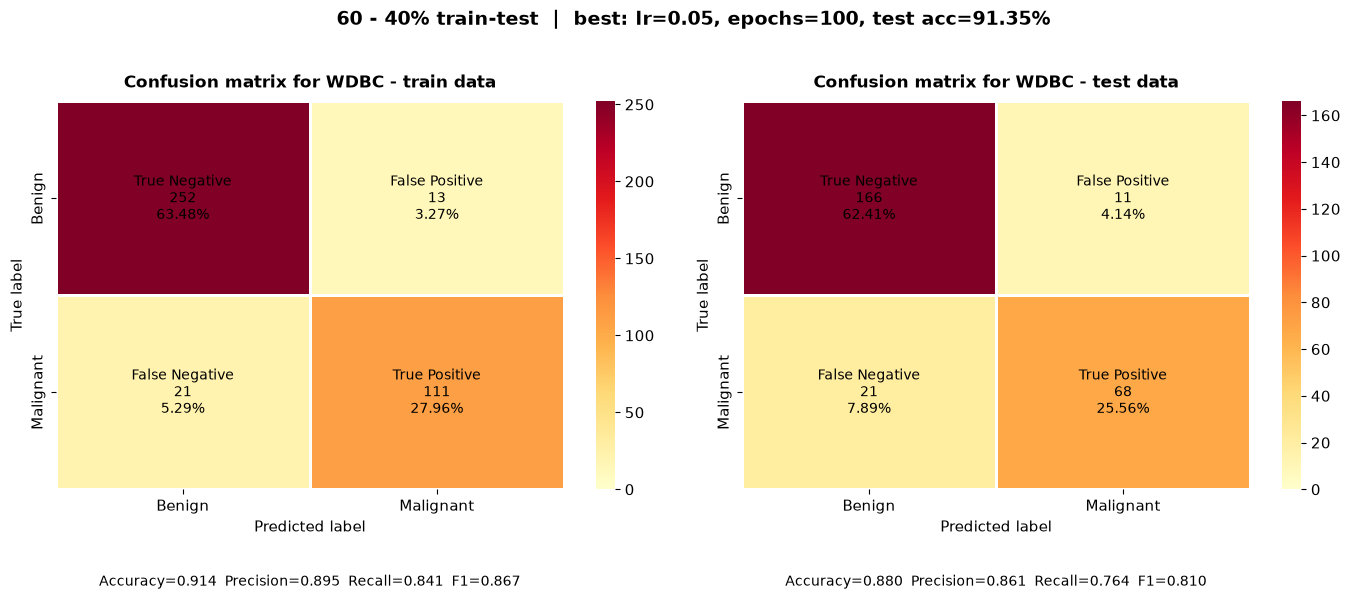

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

Saved: plots\split_cm_60_40.png
Saved: plots\split_loss_60_40.png  (lr=0.05, epochs=100)
Saved: plots\hyperparam_accuracy_60_40.png
 * Detected Sugeno model type
Exported model: models\20260628_172814_gridsearch_pca_feature_select_60_40_best_model.pkl


In [20]:
# Mỗi tỷ lệ split: vẽ biểu đồ + xuất checkpoint mô hình tốt nhất
for split_label, test_size in SPLIT_RATIOS.items():
    lr, epochs, best_acc_pct = best_config_for_split(split_label)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_663, y_663, test_size=test_size, random_state=42, stratify=y_663,
    )
    model = build_fs_and_model(X_tr, epochs)
    model, history_df = train_model(model, X_tr, y_tr, epochs, lr, return_history=True)
    y_tr_p = predict_binary(model, X_tr)
    y_te_p = predict_binary(model, X_te)
    slug = split_label.replace("-", "_")
    title_suffix = f"best: lr={lr}, epochs={epochs}, test acc={best_acc_pct:.2f}%"

    fig_cm, axes = plt.subplots(1, 2, figsize=(14, 6))
    plot_confusion_matrix(axes[0], y_tr, y_tr_p, "Confusion matrix for WDBC - train data")
    plot_confusion_matrix(axes[1], y_te, y_te_p, "Confusion matrix for WDBC - test data")
    fig_cm.suptitle(f"{SPLIT_TITLES[split_label]}  |  {title_suffix}", fontsize=14, fontweight="bold", y=1.02)
    fig_cm.tight_layout()

    fig_loss, ax_loss = plt.subplots(figsize=(9, 5.5))
    plot_loss_curve(ax_loss, history_df, lr, epochs, best_acc_pct)
    fig_loss.tight_layout()

    fig_bar, _ = plot_grouped_accuracy(split_label)
    fig_bar.tight_layout()

    for fig in (fig_cm, fig_loss, fig_bar):
        plt.figure(fig.number)
        plt.show()

    paths = {
        "cm": PLOT_DIR / f"split_cm_{slug}.png",
        "loss": PLOT_DIR / f"split_loss_{slug}.png",
        "bar": PLOT_DIR / f"hyperparam_accuracy_{slug}.png",
    }
    fig_cm.savefig(paths["cm"], dpi=200, bbox_inches="tight")
    fig_loss.savefig(paths["loss"], dpi=200, bbox_inches="tight")
    fig_bar.savefig(paths["bar"], dpi=200, bbox_inches="tight")
    plt.close(fig_cm)
    plt.close(fig_loss)
    plt.close(fig_bar)
    print(
        f"Saved: {paths['cm']}\n"
        f"Saved: {paths['loss']}  (lr={lr}, epochs={epochs})\n"
        f"Saved: {paths['bar']}"
    )

    model_path = OUT_DIR / f"{STAMP}_{RUN_TAG}_{slug}_best_model.pkl"
    model.save(str(model_path))

    loss_log_path = OUT_DIR / f"{STAMP}_{RUN_TAG}_{slug}_training_loss_log.csv"
    history_df.to_csv(loss_log_path, index=False)

    membership_path = OUT_DIR / f"{STAMP}_{RUN_TAG}_{slug}_membership_functions.csv"
    export_trained_membership(model).to_csv(membership_path, index=False)

    metrics_path = OUT_DIR / f"{STAMP}_{RUN_TAG}_{slug}_metrics.json"
    metrics_payload = {
        "timestamp": STAMP,
        "run_tag": RUN_TAG,
        "split_ratio": split_label,
        "learning_rate": lr,
        "epochs": epochs,
        "test_accuracy_pct": best_acc_pct,
        "metrics": {
            "TRAIN": evaluate_split_metrics(y_tr, y_tr_p, "TRAIN"),
            "TEST": evaluate_split_metrics(y_te, y_te_p, "TEST"),
        },
        "model_path": str(model_path),
        "loss_log_path": str(loss_log_path),
        "membership_csv_path": str(membership_path),
    }
    with open(metrics_path, "w", encoding="utf-8") as f:
        json.dump(metrics_payload, f, indent=2, ensure_ascii=False)

    split_exports[split_label] = {
        "split_ratio": split_label,
        "test_size": test_size,
        "train_size": len(X_tr),
        "test_n": len(X_te),
        "learning_rate": lr,
        "epochs": epochs,
        "test_accuracy_pct": best_acc_pct,
        "model_path": str(model_path),
        "loss_log_path": str(loss_log_path),
        "metrics_json_path": str(metrics_path),
        "membership_csv_path": str(membership_path),
        "mf_init_log": mf_init_log_from_train(X_tr),
        "grid_rules": GRID_RULES,
    }
    print(f"Exported model: {model_path}")

## 6. Xuất artifact dùng chung vào `models/`

Lưu scaler, meta tổng hợp và danh sách 27 luật — dùng kèm checkpoint từng split ở bước 5.

| File | Nội dung |
|------|----------|
| `{stamp}_{run_tag}_scaler.pkl` | `StandardScaler` fit trên 9 feature (trước quality drop) |
| `{stamp}_{run_tag}_meta.json` | Tiền xử lý, PCA, cấu hình tốt nhất mỗi split |
| `{stamp}_{run_tag}_fuzzy_rules.csv` | 27 luật grid (khởi tạo) |
| `{stamp}_{run_tag}_{split}_best_model.pkl` | Checkpoint ANFIS (đã lưu ở bước 5) |

In [21]:
scaler_path = OUT_DIR / f"{STAMP}_{RUN_TAG}_scaler.pkl"
meta_path = OUT_DIR / f"{STAMP}_{RUN_TAG}_meta.json"
rules_path = OUT_DIR / f"{STAMP}_{RUN_TAG}_fuzzy_rules.csv"

with open(scaler_path, "wb") as f:
    pickle.dump(scaler, f)

fuzzy_rules_df.to_csv(rules_path, index=False)

meta_payload = {
    "timestamp": STAMP,
    "run_tag": RUN_TAG,
    "dataset": "UCI WBCD original",
    "n_features_raw": len(feature_cols),
    "feature_selection_method": "Paper Table 8: PCA on 9 normalized features; fixed v1/v2/v3",
    "paper_top3_cumulative_pca_importance_pct": round(
        float(pca_full.explained_variance_ratio_[:3].sum() * 100), 4
    ),
    "pca_table8": pca_table_df[["Attribute No.", "Feature", "Percentage of Importance"]].to_dict(orient="records"),
    "selected_features": PAPER_TOP3_FEATURES,
    "pca_explained_variance_ratio": [float(x) for x in pca_full.explained_variance_ratio_],
    "split_mode": "grid search 80/20, 70/30, 60/40 (stratified, random_state=42)",
    "outlier_method": "Euclidean distance to data center on 9 raw features; threshold = mean + OUTLIER_STD_MULTIPLIER * std",
    "outlier_std_multiplier": OUTLIER_STD_MULTIPLIER,
    "outlier_threshold": float(outlier_threshold),
    "outliers_removed": int((~keep_mask).sum()),
    "used_samples": int(len(X_663)),
    "quality_dropped_sample_code_numbers": QUALITY_DROPPED_SAMPLE_IDS,
    "class_distribution_663": {
        "benign": int((y_663 == 0).sum()),
        "malignant": int((y_663 == 1).sum()),
    },
    "optimizer": "SGD (premise/MF only)",
    "grad_clip_norm": 1.0,
    "sigma_min": 0.001,
    "fuzzy_system": "FS() + grid 27 rules + learned consequent (zerotype=False)",
    "membership_function": "Gaussian (low / medium / high)",
    "rule_partitioning": "grid 3^3 = 27",
    "num_rules": 27,
    "scaler_path": str(scaler_path),
    "fuzzy_rules_csv_path": str(rules_path),
    "grid_results_csv_path": str(RESULTS_PATH),
    "splits": split_exports,
}
with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(meta_payload, f, indent=2, ensure_ascii=False)

print(f"Saved: {scaler_path}")
print(f"Saved: {rules_path}")
print(f"Saved: {meta_path}")
for split_label, info in split_exports.items():
    print(f"  [{split_label}] {info['model_path']}")

Saved: models\20260628_172814_gridsearch_pca_feature_select_scaler.pkl
Saved: models\20260628_172814_gridsearch_pca_feature_select_fuzzy_rules.csv
Saved: models\20260628_172814_gridsearch_pca_feature_select_meta.json
  [80-20] models\20260628_172814_gridsearch_pca_feature_select_80_20_best_model.pkl
  [70-30] models\20260628_172814_gridsearch_pca_feature_select_70_30_best_model.pkl
  [60-40] models\20260628_172814_gridsearch_pca_feature_select_60_40_best_model.pkl


## 7. Tóm tắt cấu hình tốt nhất mỗi split

Bảng dưới tổng hợp learning rate và epoch có test accuracy cao nhất từ grid search.

In [22]:
best_rows = []
for split_label in SPLIT_RATIOS:
    lr, epochs, acc_pct = best_config_for_split(split_label)
    best_rows.append({
        "Split": SPLIT_TITLES[split_label],
        "Learning rate": lr,
        "Epochs": epochs,
        "Test accuracy (%)": acc_pct,
    })
display(pd.DataFrame(best_rows))

,Split,Learning rate,Epochs,Test accuracy (%)
0,80 - 20% train-test,0.05,50,95.49
1,70 - 30% train-test,0.05,100,95.98
2,60 - 40% train-test,0.05,100,91.35


## 8. Xuất nhật ký HTML vào `nhat-ky/`

Sau khi chạy xong grid search, vẽ biểu đồ và xuất mô hình, cell dưới xuất bản HTML của notebook này — dùng để tra cứu, audit và đính kèm báo cáo.

In [23]:
import subprocess
from datetime import datetime

html_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
html_trial_tag = "grid_search_pca_feature_select"
html_split_tag = "ANFIS_grid_80_20_70_30_60_40"
html_output_name = f"{html_timestamp}_{html_trial_tag}_{html_split_tag}.html"
notebook_path = Path("anfis_pca_scikit_anfis_training.ipynb")

result = subprocess.run(
    [
        "jupyter", "nbconvert", "--to", "html",
        str(notebook_path),
        "--output", html_output_name,
        "--output-dir", str(LOG_DIR),
    ],
    capture_output=True,
    text=True,
)

html_path = LOG_DIR / html_output_name
if result.returncode == 0:
    print(f"Đã lưu nhật ký: {html_path}")
else:
    print("Lỗi xuất HTML:")
    print(result.stderr or result.stdout)

Đã lưu nhật ký: nhat-ky\20260628_172853_grid_search_pca_feature_select_ANFIS_grid_80_20_70_30_60_40.html
